In [1]:
import numpy as np
import glob
import torch
import json
import torch.nn.functional as F
import nibabel as nib
import huggingface_hub

from totalsegmentator.python_api import totalsegmentator
from scipy.ndimage import label, binary_closing, binary_erosion, center_of_mass
from matplotlib import pyplot as plt
from PIL import Image

from modeling.BaseModel import BaseModel
from modeling import build_model
from utilities.distributed import init_distributed
from utilities.arguments import load_opt_from_config_files
from utilities.constants import BIOMED_CLASSES


from inference_utils.inference import interactive_infer_image
from inference_utils.output_processing import dice_volume, iou_volume, hausdorff_distance_volume
from inference_utils.processing_utils import read_nifti_only, process_intensity_image, resize_to_original, volume_trimmer

c:\Users\P095392\GitProjects\BiomedParse\bio_med_venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Deformable Transformer Encoder is not available.


c:\Users\P095392\GitProjects\BiomedParse\bio_med_venv\Lib\site-packages\kornia\feature\lightglue.py:30: FutureWarning: `torch.cuda.amp.custom_fwd(args...)` is deprecated. Please use `torch.amp.custom_fwd(args..., device_type='cuda')` instead.
  @torch.cuda.amp.custom_fwd(cast_inputs=torch.float32)
c:\Users\P095392\GitProjects\BiomedParse\bio_med_venv\Lib\site-packages\transformers\utils\generic.py:311: FutureWarning: `torch.utils._pytree._register_pytree_node` is deprecated. Please use `torch.utils._pytree.register_pytree_node` instead.
  torch.utils._pytree._register_pytree_node(


In [2]:
with open('tokens.json') as f:
    tokens = json.load(f)

In [3]:
HF_TOKEN = tokens['hugging_face']

huggingface_hub.login(HF_TOKEN)

Token will not been saved to git credential helper. Pass `add_to_git_credential=True` if you want to set the git credential as well.
Token is valid (permission: read).
Your token has been saved to C:\Users\P095392\.cache\huggingface\token
Login successful


### Model Setup

In [2]:
opt = load_opt_from_config_files(["configs/biomedparse_inference.yaml"])
opt = init_distributed(opt)

# Load model from pretrained weights
pretrained_pth = 'model_state_FULL_CT.pt'
# pretrained_pth = 'pretrained\\biomedparse_v1.pt'
#pretrained_pth = 'model_weights,LR=10^-5,batch=1,ontlyTumors.pt'
# pretrained_pth = 'model_weights,LR=10^-5,batch=1,abomen_tumor,frozen=7.pt'

# pretrained_pth = 'hf_hub:microsoft/BiomedParse'

model = BaseModel(opt, build_model(opt)).from_pretrained(pretrained_pth).eval().cuda()
# model.load_state_dict(torch.load('pretrained\\module_training_states,LR=10^-7,batch=1,onlyTumors.pt', weights_only=True))
with torch.no_grad():
    model.model.sem_seg_head.predictor.lang_encoder.get_text_embeddings(BIOMED_CLASSES + ["background"], is_eval=True)
print(pretrained_pth)


c:\Users\P095392\GitProjects\BiomedParse\bio_med_venv\Lib\site-packages\transformers\utils\generic.py:311: FutureWarning: `torch.utils._pytree._register_pytree_node` is deprecated. Please use `torch.utils._pytree.register_pytree_node` instead.
  torch.utils._pytree._register_pytree_node(
*UNLOADED* backbone.layers.0.blocks.0.mlp.f_lora_A_1.weight, Model Shape: torch.Size([1, 192])
*UNLOADED* backbone.layers.0.blocks.0.mlp.f_lora_A_2.weight, Model Shape: torch.Size([1, 768])
*UNLOADED* backbone.layers.0.blocks.0.mlp.f_lora_B_1.weight, Model Shape: torch.Size([768, 1])
*UNLOADED* backbone.layers.0.blocks.0.mlp.f_lora_B_2.weight, Model Shape: torch.Size([192, 1])
*UNLOADED* backbone.layers.0.blocks.0.modulation.f_lora_A.weight, Model Shape: torch.Size([1, 192])
*UNLOADED* backbone.layers.0.blocks.0.modulation.f_lora_B.weight, Model Shape: torch.Size([389, 1])
*UNLOADED* backbone.layers.0.blocks.1.mlp.f_lora_A_1.weight, Model Shape: torch.Size([1, 192])
*UNLOADED* backbone.layers.0.blocks.

model_state_FULL_CT.pt


### Utility Functions

In [3]:
!pip install pydicom nibabel SimpleITK


def inference_nifti(image, text_prompts, is_CT, site=None):
    # image, nii = read_nifti_only(file_path)
    test_3D = np.zeros((image.shape[2], image.shape[0], image.shape[1]))

    for slice_iter in range(image.shape[2]):
        
        # Resize and padding
        image_array = process_intensity_image(image[: ,: , slice_iter], is_CT, site)
            
        # Get prediction
        pred_mask = interactive_infer_image(model, Image.fromarray(image_array), text_prompts)
        # pred_mask = (pred_mask > 0.5).astype(np.uint8)

        # Resize to original size
        resize_image = resize_to_original(pred_mask, image.shape[0], image.shape[1])

        # Stack back together
        test_3D[slice_iter] = resize_image.squeeze()


    # print(f"Patient {file_path[14:20]} is complete")

    assert test_3D.shape[1] == test_3D.shape[2]

    final_img = test_3D.transpose(1,2,0)

    # final_img = nib.Nifti1Image(test_3D.transpose(1,2,0), nii.affine)
    # nib.save(final_img, f'results/CT_patient_kidney_{file_path[14:20]}.nii.gz')

    return final_img



[notice] A new release of pip is available: 25.0.1 -> 25.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
PDAC_patients = [100002, 100005, 100011, 100030, 100033, 100043, 100050, 100060, 100074, 100082, 100091, 100096, 100101, 100102, 100124, 100127, 100134, 100143, 100144, 100150]
len(PDAC_patients)

20

In [4]:
f = open('patients.json')
data = json.load(f)

PDAC_patients = data['patients']

longer_prompt: If the CT scan contains a pancreatic tumor, try and segment it
longer_prompt_1: Analyze the provided image. If pancreatic acncer is present, segment the affected area. If no cancer is found avoid segmentation.
longer_prompt_2: Highlight only visible pancreatic cancer regions, leaving out uncertain areas
longer_prompt_3: Highlight only visible pancreatic cancer regions in the provided CT scnas of the body, leaving out uncertain areas

In [14]:
PDAC_patients = [ 100143, 100144, 100150]

In [14]:
for p in PDAC_patients:
    img_paths = f'data//CT//img//{str(p)}*'
    is_CT = True
    # site = 'liver'
    # text_prompts = ['liver']

    results = []
    for img_path in glob.iglob(img_paths):
        print(img_path)
        print("Locating kidneys ...")

        input = nib.load(img_path)
        image = input.get_fdata()
        output = totalsegmentator(input, roi_subset_robust=['kidney_right', 'kidney_left'])


        output = output.get_fdata()

        first, last = volume_trimmer(output)

        print('\n')
        print("Pancreatic tumor segmentation ...")
        print('\n')

        image_window = np.zeros((image.shape[0], image.shape[1], image.shape[2]))

        # organs = ['gallbladder']

        pancreas_pred = inference_nifti(image[:,:,first:last], ["tumor"], is_CT=is_CT, site="abdomen")
        pancreas_pred = (pancreas_pred > 0.5).astype(np.uint8)
        # Save raw cropped scan for valid affine 
        image_window[:, :, first:last] = pancreas_pred

        # image_window_TS = np.zeros((image.shape[0], image.shape[1], image.shape[2]))
        # image_window_TS[:, :, first:last] = image[:,:, first:last]

        
        # cropped_input = nib.Nifti1Image(image_window_TS, input.affine)

        # output_2 = totalsegmentator(cropped_input, roi_subset_robust=organs)
        # nib.save(output_2, f'organ_inference/CT_patient_{img_path[14:20]}_{organs[0]}_TS_cropped.nii.gz')

        # Use TS kidney segmentation to remove possible kidney predictions from biomed
        image_window = image_window + output
        image_window[image_window > 1] = 0

        final_img = nib.Nifti1Image(image_window, input.affine)
        nib.save(final_img, f'CT_FULL_OUTPUT/CT_patient_PDAC_{str(p)}_updated_TS.nii.gz')

   

data//CT//img\100002_00001_0000.nii.gz
Locating kidneys ...

If you use this tool please cite: https://pubs.rsna.org/doi/10.1148/ryai.230024

Generating rough segmentation for cropping...
  (Using more robust (but slower) 3mm model for cropping.)
Resampling...
  Resampled in 11.24s
Predicting...


100%|██████████| 6/6 [00:00<00:00, 107.16it/s]


  Predicted in 27.72s
Resampling...
  cropping from (512, 512, 561) to (278, 154, 142)
Resampling...
  Resampled in 0.76s
Predicting part 1 of 1 ...


100%|██████████| 2/2 [00:00<00:00, 57.95it/s]


  Predicted in 20.51s
Resampling...


Pancreatic tumor segmentation ...


data//CT//img\100021_00001_0000.nii.gz
Locating kidneys ...

If you use this tool please cite: https://pubs.rsna.org/doi/10.1148/ryai.230024

Generating rough segmentation for cropping...
  (Using more robust (but slower) 3mm model for cropping.)
Resampling...
  Resampled in 2.52s
Predicting...


...

  Predicted in 14.91s
Resampling...


Pancreatic tumor segmentation ...


data//CT//img\101679_00001_0000.nii.gz
Locating kidneys ...

If you use this tool please cite: https://pubs.rsna.org/doi/10.1148/ryai.230024

Generating rough segmentation for cropping...
  (Using more robust (but slower) 3mm model for cropping.)
Resampling...
  Resampled in 7.15s
Predicting...


100%|██████████| 8/8 [00:00<00:00, 131.16it/s]


  Predicted in 18.44s
Resampling...
  cropping from (512, 512, 455) to (241, 117, 154)
Resampling...
  Resampled in 0.45s
Predicting part 1 of 1 ...


100%|██████████| 2/2 [00:00<00:00, 111.12it/s]


  Predicted in 14.44s
Resampling...


Pancreatic tumor segmentation ...




In [16]:
first, last = volume_trimmer(output)


In [26]:
patients = []

for img_path in glob.iglob('data//CT//img//*'):
    # TODO add regex for stricter selection
    patients.append(img_path[14:20])

len(patients)

514

In [4]:
# For single file test
# patients = ['100000']
"""
TODO:  Make the calculations on CUDA instead of cpu
"""
# [231:423]
for patient in PDAC_patients:

    path_label = f'data//CT//gt//{patient}_00001.nii.gz'
    label, nii = read_nifti_only(path_label)

    # One hot encode multiple classes
    unique_labels = np.unique(label)

    buffer = int(label.shape[2] * 0.05)

    label_one_hot = F.one_hot(torch.tensor(label).long(), num_classes=-1)

    label_one_hot = label_one_hot[:, :, :, 1]
    first, last = volume_trimmer(label_one_hot)

    label_one_hot = label_one_hot[:,:,first:last]

    path_pred = f'results_pub//CT_patient_{patient}_LR=-5,b=2,fullv2.nii.gz'
    pred, nii = read_nifti_only(path_pred)

    pred = pred[:, :, first:last]
    pred = torch.tensor(pred)


    # 1 is currently PDAC lessions, watch out for which label we are calculating
    if 1 not in unique_labels:
         continue
    else:
        dice = dice_volume(torch.permute(label_one_hot, (2, 0, 1)), torch.permute(pred, (2, 0, 1)))
        iou = iou_volume(torch.permute(label_one_hot, (2, 0, 1)), torch.permute(pred, (2, 0, 1)))
        hausdorff = hausdorff_distance_volume(torch.permute(label_one_hot, (2, 0, 1)), torch.permute(pred, (2, 0, 1)))

        with open("metrics_full_dataset_v2.txt", "a") as f:
            f.write(f"3D_DICE score for patient {patient} is : {dice}\n")
            f.write(f"3D_IoU score for patient {patient} is : {iou}\n")
            f.write(f"3D_HD score for patient {patient} is : {hausdorff}\n")
            f.write("\n")

    print(f"Patient {patient} done!")

# with open("final_avg.txt", "a") as f:
#         f.write(f"Dice average over 389 patients is: {np.average(dice_scores)}\n")
#         f.write(f"IoU average over 389 patients is: {np.average(iou_scores)}\n")
#         f.write(f"HD average over 389 patients is: {np.average(HD_scores)}\n")

Patient 100002 done!
Patient 100005 done!
Patient 100011 done!
Patient 100030 done!
Patient 100033 done!
Patient 100043 done!
Patient 100050 done!
Patient 100060 done!
Patient 100074 done!
Patient 100082 done!
Patient 100091 done!
Patient 100096 done!
Patient 100101 done!
Patient 100102 done!
Patient 100124 done!
Patient 100127 done!
Patient 100134 done!


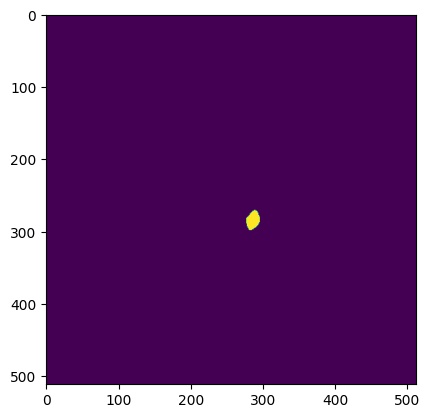

In [ ]:
imgplot = plt.imshow(torch.permute(pred, (2, 0, 1))[52])
plt.show()

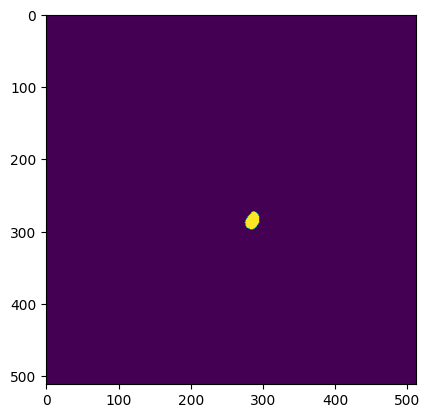

In [8]:
imgplot = plt.imshow(torch.permute(pred, (2, 0, 1))[52])
plt.show()